In [3]:
# importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# importing the data set
path=r"D:\Unified Mentor\Netflix Data\netflix1.csv"
df = pd.read_csv(path)
df.head(10) 


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
5,s9,TV Show,The Great British Baking Show,Andy Devonshire,United Kingdom,9/24/2021,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
6,s10,Movie,The Starling,Theodore Melfi,United States,9/24/2021,2021,PG-13,104 min,"Comedies, Dramas"
7,s939,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,5/1/2021,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu..."
8,s13,Movie,Je Suis Karl,Christian Schwochow,Germany,9/23/2021,2021,TV-MA,127 min,"Dramas, International Movies"
9,s940,Movie,Motu Patlu in Wonderland,Suhas Kadav,India,5/1/2021,2013,TV-Y7,76 min,"Children & Family Movies, Music & Musicals"


In [5]:
# cleaning the Data Set
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nNumber of duplicate rows:", df.duplicated().sum())
print("\nMissing values (percent):\n", (df.isnull().sum() / len(df) * 100).round(2))

Shape: (8790, 10)

Columns:
 ['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']

Data types:
 show_id         object
type            object
title           object
director        object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
dtype: object

Number of duplicate rows: 0

Missing values (percent):
 show_id         0.0
type            0.0
title           0.0
director        0.0
country         0.0
date_added      0.0
release_year    0.0
rating          0.0
duration        0.0
listed_in       0.0
dtype: float64


In [8]:
# Changing Data Types
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
print("\nData types:\n", df.dtypes)


Data types:
 show_id                 object
type                    object
title                   object
director                object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
dtype: object


In [10]:
# Adding month column
df['day_added'] = df['date_added'].dt.day
df['month_added'] = df['date_added'].dt.month
print("\nData types:\n", df.dtypes)


Data types:
 show_id                 object
type                    object
title                   object
director                object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
day_added                int32
month_added              int32
dtype: object


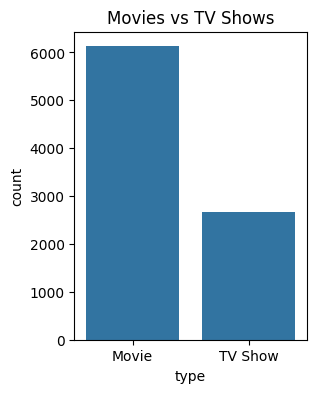

In [16]:
# Exploratory Data Analysis
# movies vs Tv shows
plt.figure(figsize=(3,4))
sns.countplot(x='type', data=df)
plt.title('Movies vs TV Shows')
plt.show()

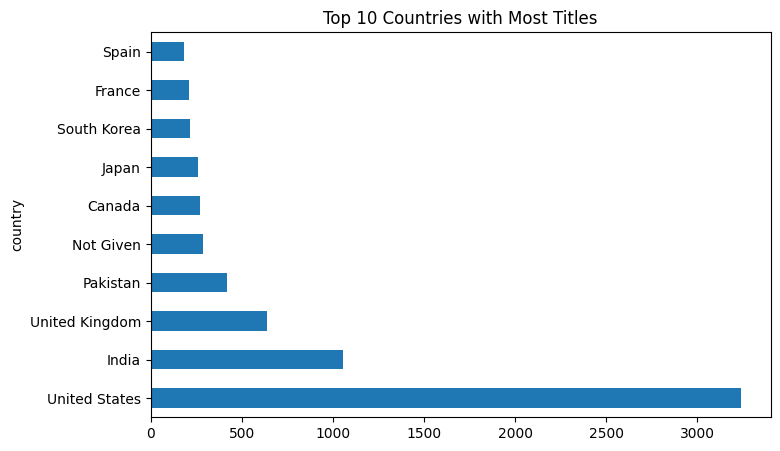

In [17]:
# Top 10 Countries
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Countries with Most Titles')
plt.show()

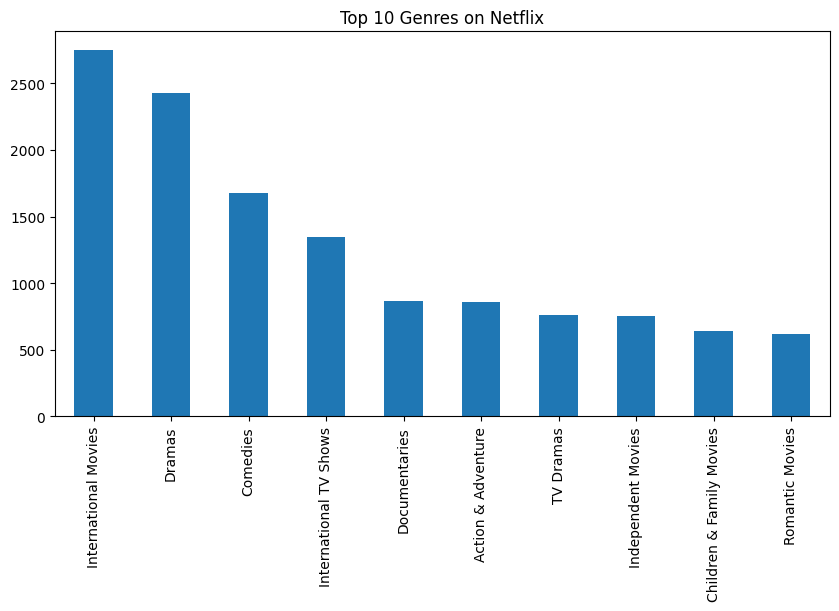

In [18]:
# Top 10 Genres
df['listed_in'] = df['listed_in'].astype(str)
from collections import Counter
genre_list = sum(df['listed_in'].str.split(',').tolist(), [])
genre_count = Counter([g.strip() for g in genre_list])
pd.Series(genre_count).nlargest(10).plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Genres on Netflix')
plt.show()

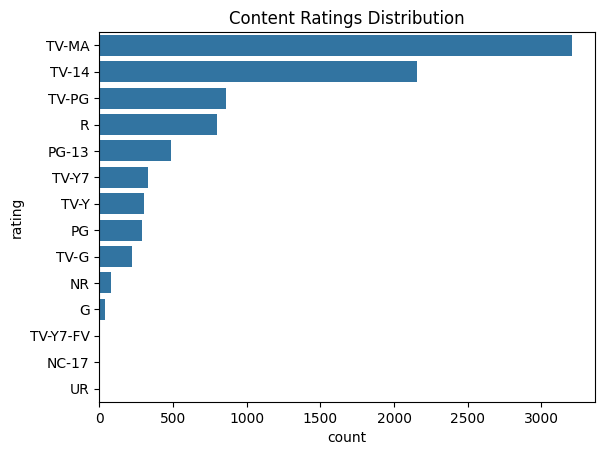

In [19]:
# Rating Distribution
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title('Content Ratings Distribution')
plt.show()

In [24]:
# Top 10 Directors
top_directors = (
    df[df['director'].notna() & (df['director'] != 'Unknown')]['director']
    .value_counts()
    .head(10)
)

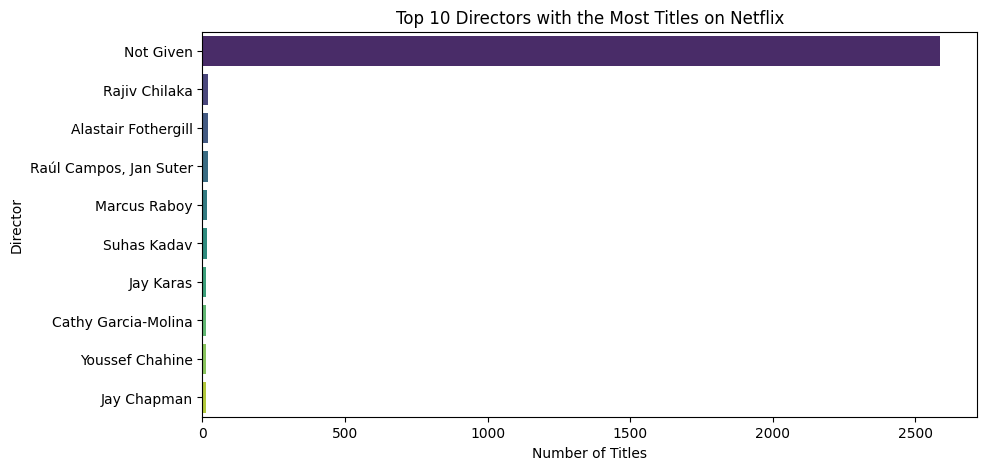

In [26]:
# Top directors with most titles
plt.figure(figsize=(10,5))
sns.barplot(x=top_directors.values, y=top_directors.index, hue=top_directors.index, palette='viridis', legend=False)
plt.title('Top 10 Directors with the Most Titles on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()

In [5]:
# content type
type_counts = df['type'].value_counts(dropna=False)
print("Content types:\n", type_counts)

Content types:
 type
Movie      6126
TV Show    2664
Name: count, dtype: int64


In [6]:
# rating distribution 
rating_counts = df['rating'].fillna('Unknown').value_counts()
print("\nTop ratings:\n", rating_counts.head(15))


Top ratings:
 rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [7]:
# top countries: 
def get_top_from_comma_col(series, top_n=10):
    vals = series.dropna().astype(str).str.split(',')
    flattened = [v.strip() for sub in vals for v in sub if isinstance(v, str)]
    return pd.Series(flattened).value_counts().head(top_n)

top_countries = get_top_from_comma_col(df['country'], top_n=15)
print("\nTop countries:\n", top_countries)


Top countries:
 United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Mexico             138
Egypt              123
Australia          114
Turkey             112
Nigeria            105
Name: count, dtype: int64


In [9]:
# top genres from listed_in
top_genres = get_top_from_comma_col(df['listed_in'], top_n=5)
print("\nTop genres (listed_in):\n", top_genres)


Top genres (listed_in):
 International Movies      2752
Dramas                    2426
Comedies                  1674
International TV Shows    1349
Documentaries              869
Name: count, dtype: int64


In [11]:
# top directors
top_directors = df['director'].fillna('Unknown').value_counts().head(10)
print("\nTop directors:\n", top_directors)


Top directors:
 director
Not Given                 2588
Rajiv Chilaka               20
Alastair Fothergill         18
Raúl Campos, Jan Suter      18
Marcus Raboy                16
Suhas Kadav                 16
Jay Karas                   14
Cathy Garcia-Molina         13
Youssef Chahine             12
Jay Chapman                 12
Name: count, dtype: int64
